## Plotting routine for the analysis

In [2]:
# Imports packages

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import ttest_1samp
import matplotlib.colors as mcolors

In [3]:
# Reads the files

y2d = xr.open_dataset("../LessOzone_2000-2005_2d.nc")
y3d = xr.open_dataset("../LessOzone_2000-2005_3d.nc")

In [4]:
# ATTENTION: Only run once!

date_floats = y2d["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
y2d = (y2d.assign_coords(time=date_dt))

date_floats = y3d["time"].values
date_strs = [str(int(d)) for d in date_floats]
date_iso = [f"{d[:4]}-{d[4:6]}-{d[6:]}" for d in date_strs]
date_dt = pd.to_datetime(date_iso)
y3d = (y3d.assign_coords(time=date_dt))

In [5]:
data = y2d.rsus.sel(time="2000-02-01T00:00:00.000000000")

In [25]:
def plot_routine(data, title):
    lon = np.rad2deg(data.clon.values)
    lat = np.rad2deg(data.clat.values)
    values = data.values

    fig = plt.figure(figsize=(12,7))
    ax = plt.axes(projection=ccrs.Mollweide())
    ax.set_global()
    ax.grid()
    ax.coastlines(resolution="110m", linewidth=1)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)

    #norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=values.min(), vmax=values.max())

    sc = ax.scatter(
        lon, lat,
        c=values,
        s=18,
        cmap="coolwarm",
        transform=ccrs.PlateCarree(),
        #norm=norm
    )

    #mask_bool = mask.values
    """
    ax.scatter(
        #lon[mask_bool],
        #lat[mask_bool],
        facecolors="none",
        edgecolors="k",
        linewidths=0.1,
        c="black",
        s=2,
        transform=ccrs.PlateCarree()
    )"""

    plt.colorbar(
        sc, ax=ax, orientation='horizontal', pad=0.05, aspect=40,
        label="Temp 2m [°C]"
    )


    #plt.savefig(savename + ".png", dpi=300, bbox_inches="tight")

    plt.show()

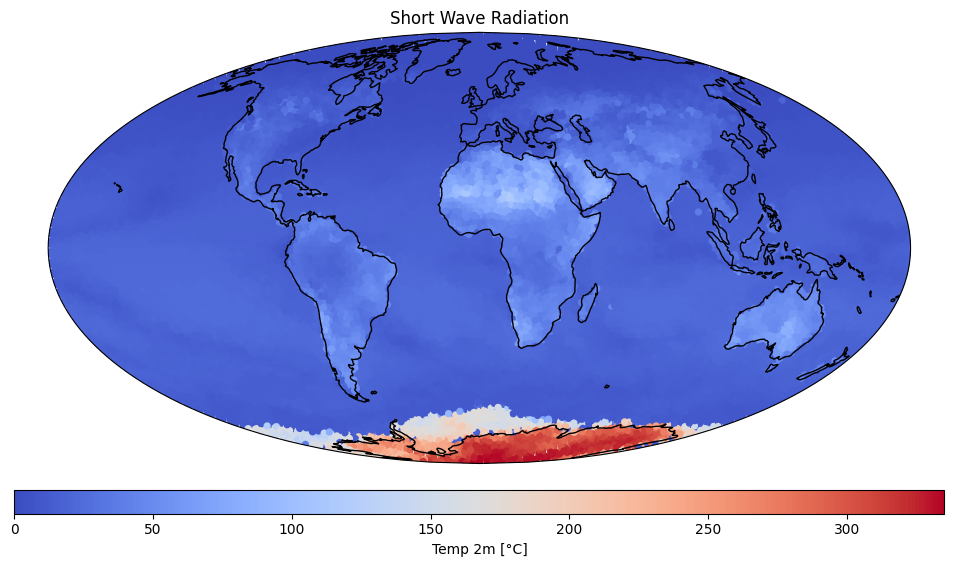

In [26]:
title = "Short Wave Radiation"
plot_routine(data, title)